# L=32 frozen ResNet-18 analysis

No spin inversion, supervised classifier, or conductance is used. Each observation is one actual saved 32x32 spin configuration (bin 1) for a seed-temperature pair. The raw-PCA notebook uses these exact same 410,000 configurations, so the representation comparison is matched observation by observation.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

L = 32
N_RUNS = 10_000
N_TEMPERATURES = 41
BINS_PER_TEMPERATURE = 10
TEMPERATURES = np.round(np.arange(2.2, 2.4001, 0.005), 3)
TC = 2.0 / np.log(1.0 + np.sqrt(2.0))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPO_ROOT = Path.home() / "senior-thesis"
RAW_ROOT = REPO_ROOT / "data/raw/ising32_tc_zoom"
OUTPUT_ROOT = REPO_ROOT / "data/processed/ising32_tc_zoom"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

runs = sorted(RAW_ROOT.glob("ising32_tc_zoom_[0-9]*"), key=lambda p: int(p.name.rsplit("_", 1)[1]))
assert len(runs) == N_RUNS, len(runs)
print(f"{len(runs):,} runs; {len(TEMPERATURES)} temperatures; device={DEVICE}")

10,000 runs; 41 temperatures; device=cuda


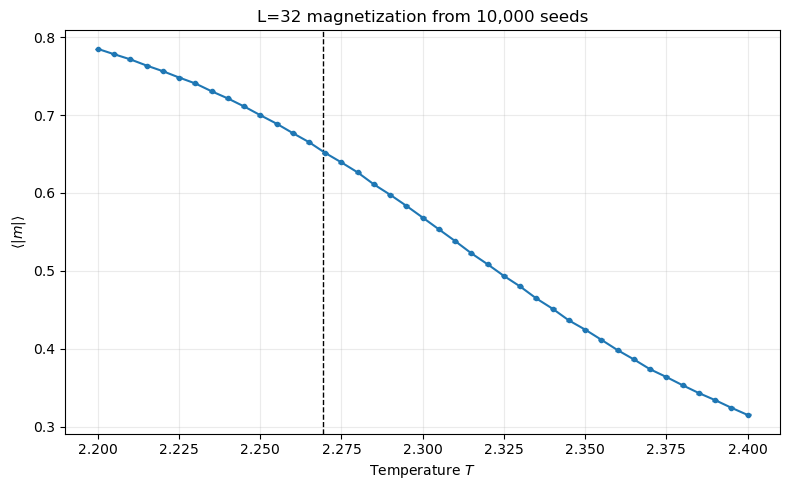

Cached matched samples for 500/10,000 runs


Cached matched samples for 1,000/10,000 runs


Cached matched samples for 1,500/10,000 runs


Cached matched samples for 2,000/10,000 runs


Cached matched samples for 2,500/10,000 runs


...

Cached matched samples for 8,000/10,000 runs


Cached matched samples for 8,500/10,000 runs


Cached matched samples for 9,000/10,000 runs


Cached matched samples for 9,500/10,000 runs


Cached matched samples for 10,000/10,000 runs


In [2]:
MEAN_SPINS_PATH = OUTPUT_ROOT / "seed_temperature_mean_spins.npy"
MAG_PATH = OUTPUT_ROOT / "seed_temperature_signed_magnetization.npy"

if not MEAN_SPINS_PATH.exists():
    mean_spins = np.lib.format.open_memmap(
        MEAN_SPINS_PATH, mode="w+", dtype=np.float16,
        shape=(N_RUNS, N_TEMPERATURES, L, L),
    )
    magnetization = np.lib.format.open_memmap(
        MAG_PATH, mode="w+", dtype=np.float32,
        shape=(N_RUNS, N_TEMPERATURES),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        mean_spins[run_index] = spins.mean(axis=1)
        magnetization[run_index] = spins.mean(axis=(1, 2, 3), dtype=np.float64)
        if (run_index + 1) % 500 == 0:
            print(f"Reduced {run_index + 1:,}/{N_RUNS:,} runs")
    mean_spins.flush(); magnetization.flush()

mean_spins = np.load(MEAN_SPINS_PATH, mmap_mode="r")
magnetization = np.load(MAG_PATH, mmap_mode="r")
assert mean_spins.shape == (N_RUNS, N_TEMPERATURES, L, L)

ABS_MAG_PATH = OUTPUT_ROOT / "seed_temperature_absolute_magnetization.npy"
if not ABS_MAG_PATH.exists():
    absolute_magnetization = np.lib.format.open_memmap(
        ABS_MAG_PATH, mode="w+", dtype=np.float32,
        shape=(N_RUNS, N_TEMPERATURES),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        configuration_m = spins.sum(axis=(2, 3), dtype=np.int32) / (L * L)
        absolute_magnetization[run_index] = np.abs(configuration_m).mean(axis=1)
        if (run_index + 1) % 500 == 0:
            print(f"Recomputed |m| for {run_index + 1:,}/{N_RUNS:,} runs")
    absolute_magnetization.flush()

absolute_magnetization = np.load(ABS_MAG_PATH, mmap_mode="r")
mean_abs_m = absolute_magnetization.mean(axis=0)
sem_abs_m = absolute_magnetization.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
assert np.all((mean_abs_m >= 0) & (mean_abs_m <= 1))
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(TEMPERATURES, mean_abs_m, yerr=sem_abs_m, marker="o", ms=3, capsize=2)
ax.axvline(TC, color="black", ls="--", lw=1)
ax.set(xlabel="Temperature $T$", ylabel=r"$\langle |m|\rangle$", title="L=32 magnetization from 10,000 seeds")
ax.grid(alpha=.25); fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising32_magnetization_zoom.png", dpi=250)
plt.show()

SAMPLE_BIN = 0
SAMPLE_SPINS_PATH = OUTPUT_ROOT / f"seed_temperature_sample_bin_{SAMPLE_BIN + 1}_spins.npy"
if not SAMPLE_SPINS_PATH.exists():
    sample_cache = np.lib.format.open_memmap(
        SAMPLE_SPINS_PATH, mode="w+", dtype=np.int8,
        shape=(N_RUNS, N_TEMPERATURES, L, L),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        sample_cache[run_index] = spins[:, SAMPLE_BIN]
        if (run_index + 1) % 500 == 0:
            print(f"Cached matched samples for {run_index + 1:,}/{N_RUNS:,} runs")
    sample_cache.flush()

sample_spins = np.load(SAMPLE_SPINS_PATH, mmap_mode="r")
sample_magnetization = sample_spins.mean(axis=(2, 3), dtype=np.float64).reshape(-1)

In [3]:
from torchvision.models import ResNet18_Weights, resnet18
import torch.nn.functional as F

EMBED_PATH = OUTPUT_ROOT / f"resnet18_sample_bin_{SAMPLE_BIN + 1}_embeddings.npy"
flat_sample_spins = sample_spins.reshape(-1, L, L)
if not EMBED_PATH.exists():
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    model.fc = torch.nn.Identity()
    model.eval().to(DEVICE)
    image_mean = torch.tensor(weights.transforms().mean, device=DEVICE).view(1, 3, 1, 1)
    image_std = torch.tensor(weights.transforms().std, device=DEVICE).view(1, 3, 1, 1)
    embedding_cache = np.lib.format.open_memmap(
        EMBED_PATH, mode="w+", dtype=np.float32,
        shape=(N_RUNS * N_TEMPERATURES, 512),
    )
    batch_size = 256
    with torch.inference_mode():
        for start in range(0, len(flat_sample_spins), batch_size):
            stop = min(start + batch_size, len(flat_sample_spins))
            images = torch.from_numpy(
                np.asarray(flat_sample_spins[start:stop], dtype=np.float32)
            ).to(DEVICE).unsqueeze(1)
            images = (images + 1.0) / 2.0
            images = images.repeat(1, 3, 1, 1)
            images = F.interpolate(images, size=(224, 224), mode="nearest")
            images = (images - image_mean) / image_std
            embedding_cache[start:stop] = model(images).cpu().numpy()
            if stop % 25_000 < batch_size:
                print(f"Embedded {stop:,}/{len(flat_sample_spins):,} matched configurations")
    embedding_cache.flush()

embeddings = np.load(EMBED_PATH, mmap_mode="r")
print(embeddings.shape)

Embedded 25,088/410,000 matched configurations


Embedded 50,176/410,000 matched configurations


Embedded 75,008/410,000 matched configurations


Embedded 100,096/410,000 matched configurations


Embedded 125,184/410,000 matched configurations


...

Embedded 325,120/410,000 matched configurations


Embedded 350,208/410,000 matched configurations


Embedded 375,040/410,000 matched configurations


Embedded 400,128/410,000 matched configurations


(410000, 512)


In [4]:
def exact_pca(features, cache_name, batch_size=4096):
    cache = OUTPUT_ROOT / cache_name
    if cache.exists():
        data = np.load(cache)
        return data["mean"], data["eigenvalues"], data["components"]
    dimension = features.shape[1]
    total = torch.zeros(dimension, dtype=torch.float64, device=DEVICE)
    second = torch.zeros((dimension, dimension), dtype=torch.float64, device=DEVICE)
    for start in range(0, len(features), batch_size):
        batch = torch.from_numpy(np.asarray(features[start:start + batch_size], dtype=np.float32)).to(DEVICE, dtype=torch.float64)
        total += batch.sum(0); second += batch.T @ batch
    mean_t = total / len(features)
    covariance = (second - len(features) * torch.outer(mean_t, mean_t)) / (len(features) - 1)
    values, vectors = torch.linalg.eigh(covariance)
    order = torch.argsort(values, descending=True)
    mean = mean_t.cpu().numpy(); eigenvalues = values[order].cpu().numpy(); components = vectors[:, order].T.cpu().numpy()
    np.savez(cache, mean=mean, eigenvalues=eigenvalues, components=components)
    return mean, eigenvalues, components

def score_memmap(features, mean, components, path, batch_size=8192):
    if path.exists(): return np.load(path, mmap_mode="r")
    scores = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(features), len(components)))
    for start in range(0, len(features), batch_size):
        stop = min(start + batch_size, len(features))
        scores[start:stop] = (np.asarray(features[start:stop], np.float32) - mean) @ components.T
    scores.flush(); return np.load(path, mmap_mode="r")

def variance_plot(eigenvalues, prefix):
    evr = eigenvalues / eigenvalues.sum(); cumulative = np.cumsum(evr)
    n90 = int(np.searchsorted(cumulative, .90) + 1)
    x = np.arange(1, n90 + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, evr[:n90], alpha=.8); ax.set(xlabel="PC", ylabel="Explained variance ratio", title=f"{prefix}: {n90} PCs retain 90%")
    other = ax.twinx(); other.plot(x, cumulative[:n90], "o-", color="tab:red", ms=3); other.axhline(.9, color="black", ls="--"); other.set_ylabel("Cumulative variance")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_variance.png", dpi=250); plt.show()
    return evr, cumulative, n90

def pc_visuals(scores, prefix):
    grids = sample_spins.reshape(-1, L, L)
    tail = max(1, int(.02 * len(scores)))

    raw_fig, raw_axes = plt.subplots(5, 3, figsize=(8, 13), constrained_layout=True)
    centered_fig, centered_axes = plt.subplots(5, 3, figsize=(8, 13), constrained_layout=True)

    column_titles = ("Lowest 2% of PC scores", "Highest 2% of PC scores", "High − low")
    for column, title in enumerate(column_titles):
        raw_axes[0, column].set_title(title)
        centered_axes[0, column].set_title(title)

    for pc in range(5):
        values = np.asarray(scores[:, pc])
        order = np.argsort(values)
        low_indices = order[:tail]
        high_indices = order[-tail:]
        low_grids = np.asarray(grids[low_indices], dtype=np.float32)
        high_grids = np.asarray(grids[high_indices], dtype=np.float32)

        low_map = low_grids.mean(axis=0)
        high_map = high_grids.mean(axis=0)
        raw_maps = (low_map, high_map, high_map - low_map)
        raw_limit = max(float(np.max(np.abs(raw_maps))), 1e-3)

        low_centered = (
            low_grids - low_grids.mean(axis=(1, 2), keepdims=True)
        ).mean(axis=0)
        high_centered = (
            high_grids - high_grids.mean(axis=(1, 2), keepdims=True)
        ).mean(axis=0)
        centered_maps = (
            low_centered,
            high_centered,
            high_centered - low_centered,
        )
        centered_limit = max(float(np.max(np.abs(centered_maps))), 1e-4)

        for column, image_data in enumerate(raw_maps):
            raw_axes[pc, column].imshow(
                image_data, cmap="RdBu_r", vmin=-raw_limit, vmax=raw_limit,
                interpolation="nearest",
            )
            raw_axes[pc, column].set_xticks([])
            raw_axes[pc, column].set_yticks([])

        for column, image_data in enumerate(centered_maps):
            centered_axes[pc, column].imshow(
                image_data, cmap="RdBu_r",
                vmin=-centered_limit, vmax=centered_limit,
                interpolation="nearest",
            )
            centered_axes[pc, column].set_xticks([])
            centered_axes[pc, column].set_yticks([])

        raw_axes[pc, 0].set_ylabel(f"PC{pc + 1}", fontsize=12)
        centered_axes[pc, 0].set_ylabel(f"PC{pc + 1}", fontsize=12)

    raw_fig.suptitle(f"{prefix}: spin configurations in the PC-score tails", fontsize=15)
    raw_fig.savefig(
        OUTPUT_ROOT / f"{prefix}_pc_tail_maps.png", dpi=250, bbox_inches="tight"
    )
    plt.show(); plt.close(raw_fig)

    centered_fig.suptitle(
        f"{prefix}: PC-tail patterns after subtracting each configuration's magnetization",
        fontsize=14,
    )
    centered_fig.savefig(
        OUTPUT_ROOT / f"{prefix}_pc_tail_mean_subtracted.png",
        dpi=250, bbox_inches="tight",
    )
    plt.show(); plt.close(centered_fig)

def cluster_analysis(features, scores90, prefix):
    models = {"PCA 90%": MiniBatchKMeans(3, random_state=42, batch_size=4096, n_init=20), "Full": MiniBatchKMeans(3, random_state=42, batch_size=4096, n_init=20)}
    labels = {"PCA 90%": models["PCA 90%"].fit_predict(scores90), "Full": models["Full"].fit_predict(features)}
    flat_m = sample_magnetization
    flat_t = np.tile(TEMPERATURES, N_RUNS)
    rows=[]
    for method, lab in labels.items():
        order=np.argsort([flat_m[lab==c].mean() for c in range(3)]); remap=np.empty(3,int); remap[order]=np.arange(3); lab=remap[lab]; labels[method]=lab
        for ti,t in enumerate(TEMPERATURES):
            at=lab[flat_t==t]
            for c in range(3): rows.append({"method":method,"temperature":t,"cluster":c,"fraction":float(np.mean(at==c))})
    table=pd.DataFrame(rows); table.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_populations.csv",index=False)
    fig,axes=plt.subplots(1,2,figsize=(14,5),sharex=True,sharey=True)
    for ax,method in zip(axes,labels):
        for c in range(3):
            d=table[(table.method==method)&(table.cluster==c)]; ax.plot(d.temperature,d.fraction,"o-",ms=3,label=f"Cluster {c}")
        ax.axvline(TC,color="black",ls="--"); ax.set(title=method,xlabel="T",ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend()
    axes[0].set_ylabel("Cluster fraction"); fig.suptitle(f"{prefix} unsupervised clusters"); fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_cluster_populations.png",dpi=250); plt.show()
    np.savez(OUTPUT_ROOT / f"{prefix}_cluster_labels.npz",pca90=labels["PCA 90%"],full=labels["Full"])
    return labels

/tmp/ipykernel_76663/3607989294.py:10: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  batch = torch.from_numpy(np.asarray(features[start:start + batch_size], dtype=np.float32)).to(DEVICE, dtype=torch.float64)


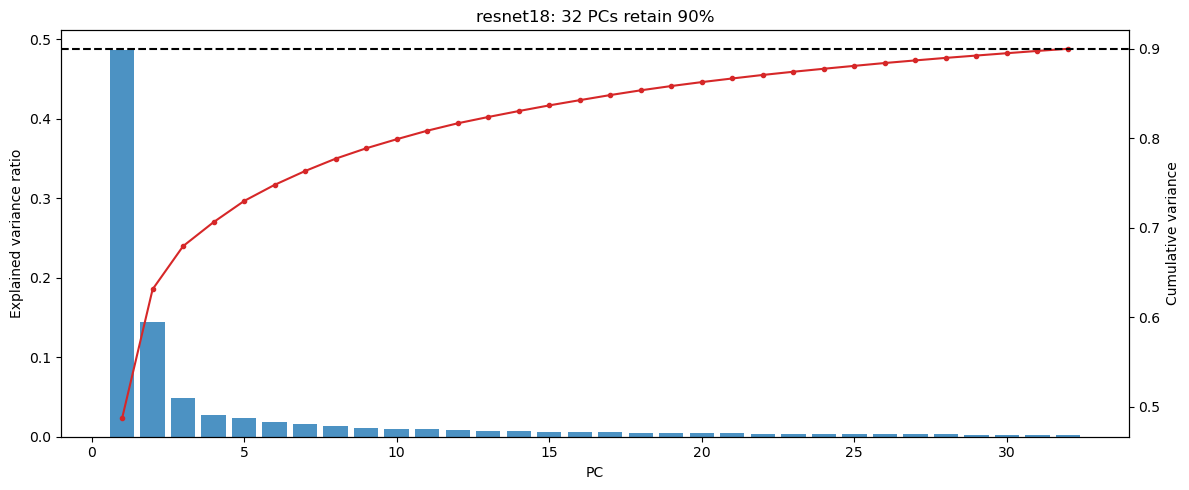

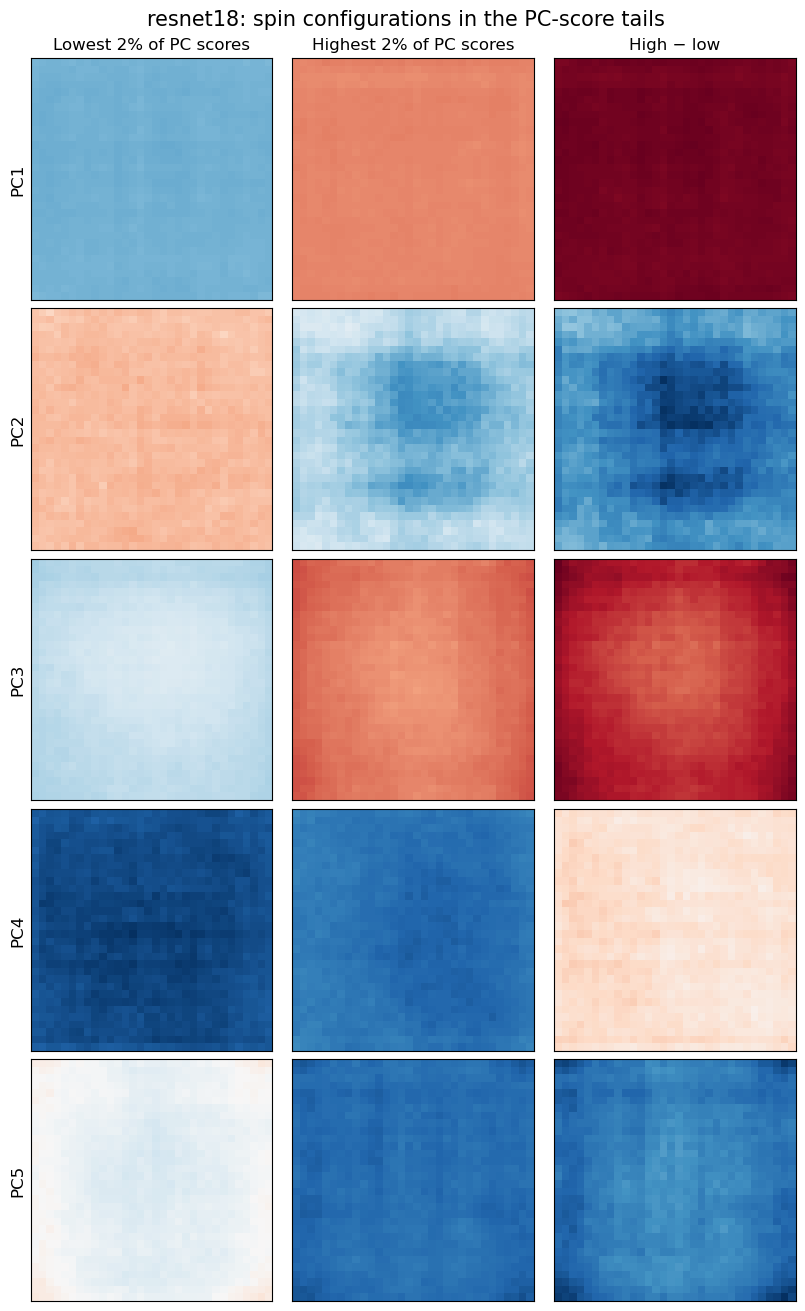

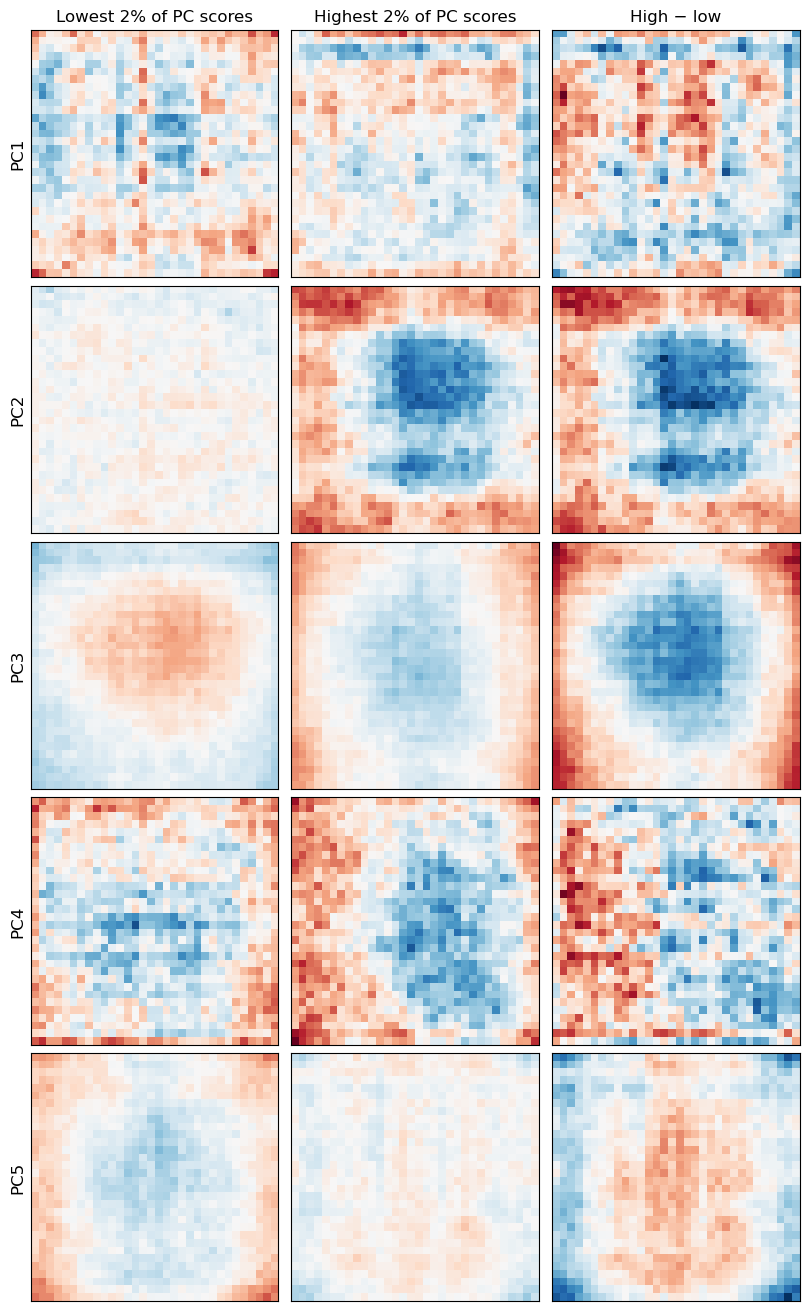

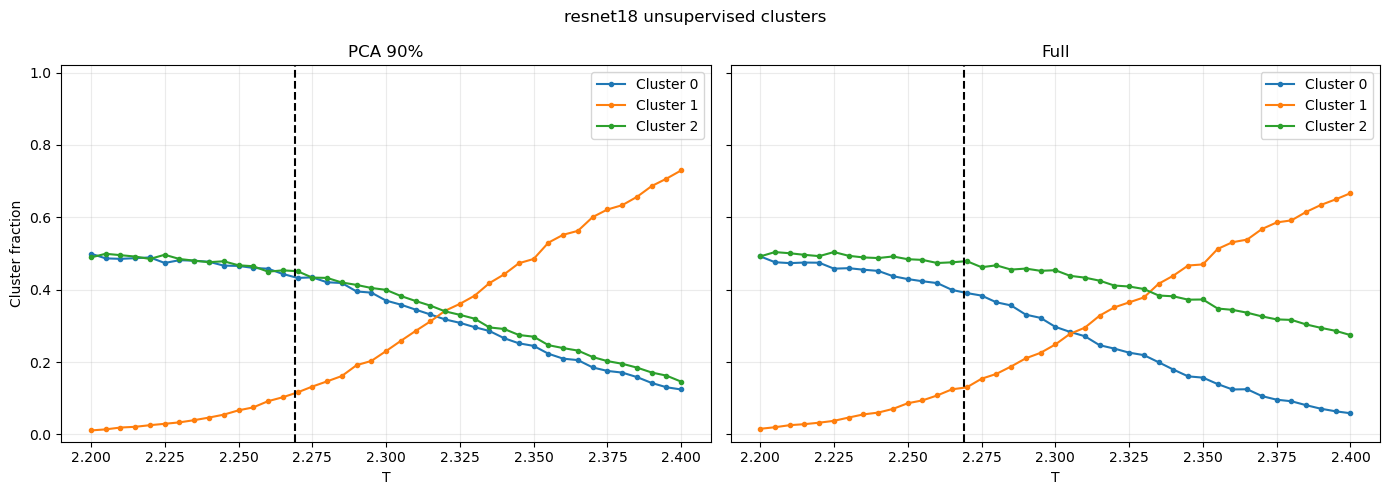

In [5]:
feature_mean,eigenvalues,components=exact_pca(embeddings,"resnet18_sample_pca.npz")
evr,cumulative,n90=variance_plot(eigenvalues,"resnet18")
scores=score_memmap(embeddings,feature_mean,components[:n90],OUTPUT_ROOT/"resnet18_sample_pca90_scores.npy")
pc_visuals(scores,"resnet18")
resnet_labels=cluster_analysis(embeddings,scores,"resnet18")
with open(OUTPUT_ROOT/"resnet18_summary.json","w") as f: json.dump({"n_components_90":n90,"variance_first5":evr[:5].tolist()},f,indent=2)